In [2]:
import subprocess
subprocess.run(['py', '-m', 'pip', 'install', 'plotly'])
print("Plotly installed!")

Plotly installed!


In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots

print("All libraries imported!")

All libraries imported!


In [4]:
df = pd.read_csv(r'C:\Users\Admin\OneDrive\Desktop\Applex\cleaned_ecommerce_data.csv')
print("Dataset loaded!")
print("Shape:", df.shape)
df.head()

Dataset loaded!
Shape: (1000, 23)


,Order_ID,Customer_ID,Customer_Name,Category,Sub_Category,Product_Name,Order_Date,Ship_Date,Region,City,...,Profit,Payment_Mode,Customer_Age,Rating,Order_Year,Order_Month,Order_Month_Name,Delivery_Days,Profit_Margin,Age_Group
0,ORD0001,CUST103,Vijay,Sports,Shirt,Mixer,2023-01-01 00:00:00,2023-01-03 00:00:00,North,Hyderabad,...,477.63,Net Banking,41.0,1.0,2023,1,January,2,18.69,Adult
1,ORD0002,CUST180,Deepa,Books,Shirt,Samsung TV,2023-01-01 08:00:00,2023-01-03 08:00:00,East,Mumbai,...,4415.49,COD,26.0,1.0,2023,1,January,2,37.96,Young Adult
2,ORD0003,CUST093,Sneha,Sports,Mobile,Python Book,2023-01-01 16:00:00,2023-01-03 16:00:00,North,Chennai,...,8819.19,UPI,32.0,4.0,2023,1,January,2,19.65,Young Adult
3,ORD0004,CUST015,Priya,Clothing,Novel,iPhone 14,2023-01-02 00:00:00,2023-01-04 00:00:00,North,Hyderabad,...,6233.29,Net Banking,52.0,5.0,2023,1,January,2,48.38,Senior
4,ORD0005,CUST107,Anita,Electronics,Shoes,Samsung TV,2023-01-02 08:00:00,2023-01-04 08:00:00,North,Delhi,...,3843.27,UPI,41.0,4.0,2023,1,January,2,34.59,Adult


In [6]:
total_revenue = df['Sales'].sum()
total_profit = df['Profit'].sum()
avg_order_value = df['Sales'].mean()
profit_margin = (df['Profit'].sum() / df['Sales'].sum() * 100).round(2)
total_orders = len(df)

print("=" * 50)
print("CORE KPIs")
print("=" * 50)
print(f"Total Revenue:    Rs.{total_revenue:,.2f}")
print(f"Total Profit:     Rs.{total_profit:,.2f}")
print(f"Avg Order Value:  Rs.{avg_order_value:,.2f}")
print(f"Profit Margin:    {profit_margin}%")
print(f"Total Orders:     {total_orders}")
print("=" * 50)

CORE KPIs
Total Revenue:    Rs.24,877,971.86
Total Profit:     Rs.4,875,553.05
Avg Order Value:  Rs.24,877.97
Profit Margin:    19.6%
Total Orders:     1000


In [8]:
import datetime

df['Order_Date'] = pd.to_datetime(df['Order_Date'])
snapshot_date = df['Order_Date'].max() + pd.Timedelta(days=1)

rfm = df.groupby('Customer_Name').agg({
    'Order_Date': lambda x: (snapshot_date - x.max()).days,
    'Order_ID': 'count',
    'Sales': 'sum'
}).reset_index()

rfm.columns = ['Customer_Name', 'Recency', 'Frequency', 'Monetary']

# Fixed scoring using rank
rfm['R_Score'] = pd.qcut(rfm['Recency'].rank(method='first'), q=4, labels=[4,3,2,1])
rfm['F_Score'] = pd.qcut(rfm['Frequency'].rank(method='first'), q=4, labels=[1,2,3,4])
rfm['M_Score'] = pd.qcut(rfm['Monetary'].rank(method='first'), q=4, labels=[1,2,3,4])

def segment(row):
    score = int(row['R_Score']) + int(row['F_Score']) + int(row['M_Score'])
    if score >= 10: return 'Champions'
    elif score >= 7: return 'Loyal Customers'
    elif score >= 5: return 'At Risk'
    else: return 'Lost'

rfm['Segment'] = rfm.apply(segment, axis=1)
print("RFM Analysis Done!")
print(rfm['Segment'].value_counts())
rfm.head()

RFM Analysis Done!
Segment
Loyal Customers    3
Champions          2
At Risk            2
Lost               1
Name: count, dtype: int64


,Customer_Name,Recency,Frequency,Monetary,R_Score,F_Score,M_Score,Segment
0,Amit,3,132,3294011.30,2,3,4,Loyal Customers
1,Anita,5,118,2842860.53,1,1,1,Lost
2,Deepa,1,130,3251276.54,4,3,3,Champions
3,Priya,3,123,3079734.68,2,2,2,At Risk
4,Rahul,2,135,3366491.98,3,4,4,Champions


In [9]:
fig = px.pie(rfm, 
             names='Segment', 
             title='Customer Segments',
             color_discrete_sequence=px.colors.qualitative.Set3)
fig.show()
print("RFM Chart done!")


RFM Chart done!


In [10]:
fig = make_subplots(
    rows=2, cols=2,
    subplot_titles=('Monthly Revenue', 'Sales by Category',
                    'Top 5 Products', 'Profit by Region')
)

# Chart 1 - Monthly Revenue
monthly = df.groupby('Order_Month')['Sales'].sum().reset_index()
fig.add_trace(go.Scatter(x=monthly['Order_Month'], y=monthly['Sales'],
              mode='lines+markers', name='Monthly Revenue'), row=1, col=1)

# Chart 2 - Category Sales
cat = df.groupby('Category')['Sales'].sum().reset_index()
fig.add_trace(go.Bar(x=cat['Category'], y=cat['Sales'],
              name='Category'), row=1, col=2)

# Chart 3 - Top 5 Products
top5 = df.groupby('Product_Name')['Sales'].sum().sort_values(ascending=False).head(5).reset_index()
fig.add_trace(go.Bar(x=top5['Sales'], y=top5['Product_Name'],
              orientation='h', name='Products'), row=2, col=1)

# Chart 4 - Profit by Region
reg = df.groupby('Region')['Profit'].sum().reset_index()
fig.add_trace(go.Bar(x=reg['Region'], y=reg['Profit'],
              name='Region Profit'), row=2, col=2)

fig.update_layout(height=700, title_text="Sales Analytics Dashboard", showlegend=False)
fig.write_html('task3_dashboard.html')
fig.show()
print("Dashboard saved as task3_dashboard.html!")

Dashboard saved as task3_dashboard.html!


In [11]:
payment = df.groupby('Payment_Mode')['Sales'].sum().reset_index()
fig = px.pie(payment, 
             names='Payment_Mode', 
             values='Sales',
             title='Sales by Payment Mode',
             color_discrete_sequence=px.colors.qualitative.Pastel)
fig.show()
print("Payment mode chart done!")

Payment mode chart done!


In [12]:
age = df.groupby('Age_Group')['Sales'].sum().reset_index()
fig = px.bar(age,
             x='Age_Group',
             y='Sales',
             title='Sales by Age Group',
             color='Age_Group',
             color_discrete_sequence=px.colors.qualitative.Set2)
fig.show()
print("Age group chart done!")

Age group chart done!


In [13]:
city = df.groupby('City')['Sales'].sum().sort_values(ascending=False).reset_index()
fig = px.bar(city,
             x='City',
             y='Sales',
             title='Sales by City',
             color='Sales',
             color_continuous_scale='Blues')
fig.show()
print("City analysis done!")

City analysis done!


In [14]:
fig = px.scatter(df,
                 x='Discount',
                 y='Profit',
                 color='Category',
                 title='Discount vs Profit by Category',
                 size='Sales')
fig.show()
print("Discount vs Profit chart done!")

Discount vs Profit chart done!


In [15]:
rating = df.groupby('Rating')['Sales'].sum().reset_index()
fig = px.bar(rating,
             x='Rating',
             y='Sales',
             title='Sales by Customer Rating',
             color='Rating',
             color_continuous_scale='Viridis')
fig.show()
print("Rating analysis done!")

Rating analysis done!


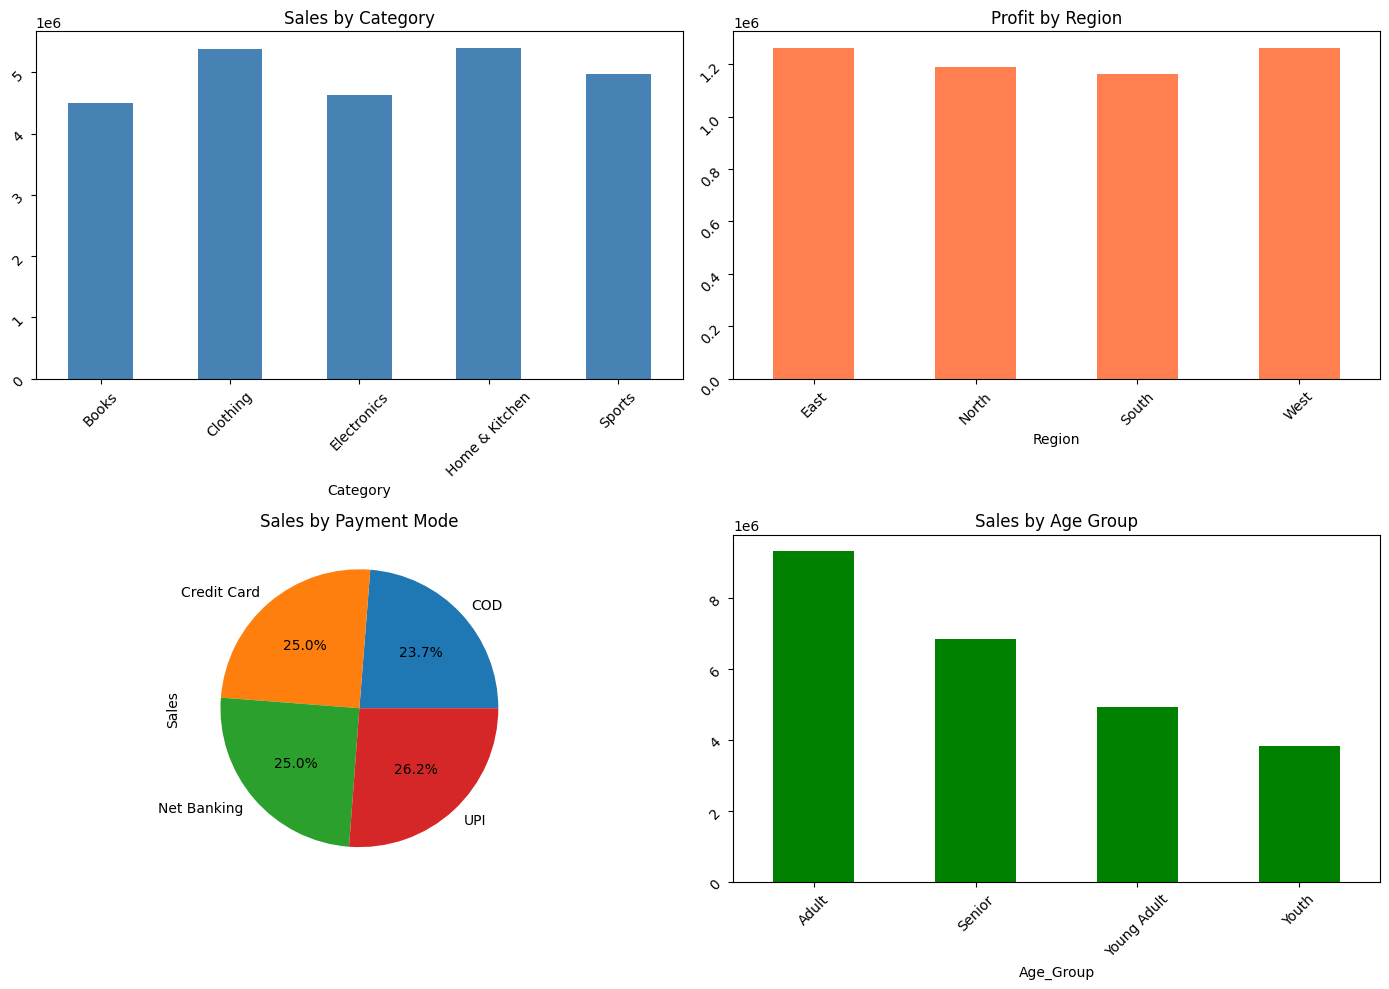

Static charts saved!


In [16]:
# Save static charts
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

df.groupby('Category')['Sales'].sum().plot(kind='bar', ax=axes[0,0], color='steelblue')
axes[0,0].set_title('Sales by Category')
axes[0,0].tick_params(rotation=45)

df.groupby('Region')['Profit'].sum().plot(kind='bar', ax=axes[0,1], color='coral')
axes[0,1].set_title('Profit by Region')
axes[0,1].tick_params(rotation=45)

df.groupby('Payment_Mode')['Sales'].sum().plot(kind='pie', ax=axes[1,0], autopct='%1.1f%%')
axes[1,0].set_title('Sales by Payment Mode')

df.groupby('Age_Group')['Sales'].sum().plot(kind='bar', ax=axes[1,1], color='green')
axes[1,1].set_title('Sales by Age Group')
axes[1,1].tick_params(rotation=45)

plt.tight_layout()
plt.savefig('task3_charts.png')
plt.show()
print("Static charts saved!")

In [18]:
print("=" * 50)
print("TASK 3 COMPLETE!")
print("=" * 50)
print(f"Total Revenue:   Rs.{df['Sales'].sum():,.2f}")
print(f"Total Profit:    Rs.{df['Profit'].sum():,.2f}")
print(f"Avg Order Value: Rs.{df['Sales'].mean():,.2f}")
print(f"Total Orders:    {len(df)}")
print("\nCustomer Segments:")
print(rfm['Segment'].value_counts())
print("\nFiles saved:")
print("  - task3_dashboard.html")
print("  - task3_charts.png")
print("=" * 50)

TASK 3 COMPLETE!
Total Revenue:   Rs.24,877,971.86
Total Profit:    Rs.4,875,553.05
Avg Order Value: Rs.24,877.97
Total Orders:    1000

Customer Segments:
Segment
Loyal Customers    3
Champions          2
At Risk            2
Lost               1
Name: count, dtype: int64

Files saved:
  - task3_dashboard.html
  - task3_charts.png


In [1]:
import subprocess
subprocess.run(['py', '-m', 'pip', 'install', 'openpyxl'])
print("openpyxl installed!")

openpyxl installed!


In [3]:
import openpyxl
from openpyxl import Workbook
from openpyxl.styles import Font, PatternFill, Alignment, Border, Side
from openpyxl.utils import get_column_letter

wb = Workbook()
ws = wb.active
ws.title = "KPI Dashboard"

# Colors
blue = "1F4E79"
light_blue = "BDD7EE"
green = "375623"
light_green = "E2EFDA"
orange = "C55A11"
light_orange = "FCE4D6"
gray = "808080"
light_gray = "F2F2F2"

# Title
ws.merge_cells('A1:F1')
ws['A1'] = 'E-COMMERCE SALES DASHBOARD'
ws['A1'].font = Font(bold=True, size=16, color="FFFFFF")
ws['A1'].fill = PatternFill("solid", fgColor=blue)
ws['A1'].alignment = Alignment(horizontal='center', vertical='center')
ws.row_dimensions[1].height = 40

# Subtitle
ws.merge_cells('A2:F2')
ws['A2'] = 'ApexPlanet Internship - Task 3 KPI Dashboard'
ws['A2'].font = Font(bold=True, size=11, color=gray)
ws['A2'].alignment = Alignment(horizontal='center')
ws.row_dimensions[2].height = 20

print("Workbook created!")


Workbook created!


In [9]:
import pandas as pd
import numpy as np

df = pd.read_csv(r'C:\Users\Admin\OneDrive\Desktop\Applex\cleaned_ecommerce_data.csv')
print("Dataset loaded!")
print("Shape:", df.shape)

Dataset loaded!
Shape: (1000, 23)


In [11]:
# Add Sales by Region Sheet
ws2 = wb.create_sheet("Sales by Region")

# Headers
headers = ['Region', 'Total Sales', 'Total Profit', 'Total Orders', 'Profit Margin %']
for col, header in enumerate(headers, 1):
    cell = ws2.cell(row=1, column=col)
    cell.value = header
    cell.font = Font(bold=True, color="FFFFFF")
    cell.fill = PatternFill("solid", fgColor="2E75B6")
    cell.alignment = Alignment(horizontal='center')

# Data
region_data = df.groupby('Region').agg({
    'Sales': 'sum',
    'Profit': 'sum',
    'Order_ID': 'count'
}).reset_index()
region_data['Profit_Margin'] = (region_data['Profit'] / region_data['Sales'] * 100).round(2)

for row, data in enumerate(region_data.values, 2):
    for col, value in enumerate(data, 1):
        cell = ws2.cell(row=row, column=col)
        if isinstance(value, float):
            cell.value = round(value, 2)
        else:
            cell.value = value
        cell.alignment = Alignment(horizontal='center')
        if row % 2 == 0:
            cell.fill = PatternFill("solid", fgColor=light_blue)

print("Sales by Region sheet added!")

Sales by Region sheet added!


In [12]:
# Set column widths
for col in range(1, 7):
    ws.column_dimensions[get_column_letter(col)].width = 20
    ws2.column_dimensions[get_column_letter(col)].width = 20

# Save the workbook
wb.save('task3_dashboard.xlsx')
print("Excel Dashboard saved!")
print("File: task3_dashboard.xlsx")

Excel Dashboard saved!
File: task3_dashboard.xlsx


In [13]:
import os

if os.path.exists('task3_dashboard.xlsx'):
    print("Excel file created successfully!")
    print("Location: task3_dashboard.xlsx")
    print("Sheets:")
    print("  - KPI Dashboard")
    print("  - Sales by Region")
else:
    print("File not found!")

Excel file created successfully!
Location: task3_dashboard.xlsx
Sheets:
  - KPI Dashboard
  - Sales by Region


In [14]:
from openpyxl import load_workbook

wb_check = load_workbook('task3_dashboard.xlsx')
print("Sheets in Excel file:")
for sheet in wb_check.sheetnames:
    print(f"  - {sheet}")
print("Excel file verified!")

Sheets in Excel file:
  - KPI Dashboard
  - Sales by Region
Excel file verified!


In [15]:
ws3 = wb.create_sheet("Sales by Category")

headers = ['Category', 'Total Sales', 'Total Profit', 'Total Orders', 'Avg Rating']
for col, header in enumerate(headers, 1):
    cell = ws3.cell(row=1, column=col)
    cell.value = header
    cell.font = Font(bold=True, color="FFFFFF")
    cell.fill = PatternFill("solid", fgColor="2E75B6")
    cell.alignment = Alignment(horizontal='center')

cat_data = df.groupby('Category').agg({
    'Sales': 'sum',
    'Profit': 'sum',
    'Order_ID': 'count',
    'Rating': 'mean'
}).reset_index()

for row, data in enumerate(cat_data.values, 2):
    for col, value in enumerate(data, 1):
        cell = ws3.cell(row=row, column=col)
        if isinstance(value, float):
            cell.value = round(value, 2)
        else:
            cell.value = value
        cell.alignment = Alignment(horizontal='center')
        if row % 2 == 0:
            cell.fill = PatternFill("solid", fgColor=light_green)

print("Category sheet added!")

Category sheet added!


In [16]:
ws4 = wb.create_sheet("Monthly Trend")

headers = ['Month', 'Total Sales', 'Total Profit', 'Total Orders']
for col, header in enumerate(headers, 1):
    cell = ws4.cell(row=1, column=col)
    cell.value = header
    cell.font = Font(bold=True, color="FFFFFF")
    cell.fill = PatternFill("solid", fgColor="2E75B6")
    cell.alignment = Alignment(horizontal='center')

monthly_data = df.groupby('Order_Month_Name').agg({
    'Sales': 'sum',
    'Profit': 'sum',
    'Order_ID': 'count'
}).reset_index()

for row, data in enumerate(monthly_data.values, 2):
    for col, value in enumerate(data, 1):
        cell = ws4.cell(row=row, column=col)
        if isinstance(value, float):
            cell.value = round(value, 2)
        else:
            cell.value = value
        cell.alignment = Alignment(horizontal='center')
        if row % 2 == 0:
            cell.fill = PatternFill("solid", fgColor=light_orange)

print("Monthly trend sheet added!")

Monthly trend sheet added!


In [17]:
ws5 = wb.create_sheet("Payment Mode")

headers = ['Payment Mode', 'Total Sales', 'Total Orders', 'Avg Order Value']
for col, header in enumerate(headers, 1):
    cell = ws5.cell(row=1, column=col)
    cell.value = header
    cell.font = Font(bold=True, color="FFFFFF")
    cell.fill = PatternFill("solid", fgColor="2E75B6")
    cell.alignment = Alignment(horizontal='center')

payment_data = df.groupby('Payment_Mode').agg({
    'Sales': 'sum',
    'Order_ID': 'count'
}).reset_index()
payment_data['Avg_Order'] = (payment_data['Sales'] / payment_data['Order_ID']).round(2)

for row, data in enumerate(payment_data.values, 2):
    for col, value in enumerate(data, 1):
        cell = ws5.cell(row=row, column=col)
        if isinstance(value, float):
            cell.value = round(value, 2)
        else:
            cell.value = value
        cell.alignment = Alignment(horizontal='center')
        if row % 2 == 0:
            cell.fill = PatternFill("solid", fgColor=light_gray)

print("Payment mode sheet added!")

Payment mode sheet added!


In [18]:
for col in range(1, 6):
    ws3.column_dimensions[get_column_letter(col)].width = 20
    ws4.column_dimensions[get_column_letter(col)].width = 20
    ws5.column_dimensions[get_column_letter(col)].width = 20

wb.save('task3_dashboard.xlsx')
print("=" * 50)
print("EXCEL DASHBOARD COMPLETE!")
print("=" * 50)
print("Sheets created:")
print("  - KPI Dashboard")
print("  - Sales by Region")
print("  - Sales by Category")
print("  - Monthly Trend")
print("  - Payment Mode")
print("File saved: task3_dashboard.xlsx")
print("=" * 50)

EXCEL DASHBOARD COMPLETE!
Sheets created:
  - KPI Dashboard
  - Sales by Region
  - Sales by Category
  - Monthly Trend
  - Payment Mode
File saved: task3_dashboard.xlsx


In [19]:
import os

size = os.path.getsize('task3_dashboard.xlsx')
print("=" * 50)
print("FILE VERIFIED!")
print("=" * 50)
print(f"File: task3_dashboard.xlsx")
print(f"Size: {size/1024:.2f} KB")
print("Ready for GitHub upload!")
print("=" * 50)

FILE VERIFIED!
File: task3_dashboard.xlsx
Size: 8.56 KB
Ready for GitHub upload!


In [20]:
import plotly.graph_objects as go
from plotly.subplots import make_subplots
import plotly.express as px

fig = make_subplots(
    rows=3, cols=2,
    subplot_titles=(
        'Sales by Region',
        'Profit by Category',
        'Monthly Sales Trend',
        'Sales by Payment Mode',
        'Sales by Age Group',
        'Top 5 Products'
    )
)

# Chart 1 - Sales by Region
region = df.groupby('Region')['Sales'].sum().reset_index()
fig.add_trace(go.Bar(
    x=region['Region'],
    y=region['Sales'],
    name='Region',
    marker_color='steelblue'),
    row=1, col=1)

# Chart 2 - Profit by Category
cat = df.groupby('Category')['Profit'].sum().reset_index()
fig.add_trace(go.Bar(
    x=cat['Category'],
    y=cat['Profit'],
    name='Category',
    marker_color='coral'),
    row=1, col=2)

# Chart 3 - Monthly Trend
monthly = df.groupby('Order_Month')['Sales'].sum().reset_index()
fig.add_trace(go.Scatter(
    x=monthly['Order_Month'],
    y=monthly['Sales'],
    mode='lines+markers',
    name='Monthly',
    line=dict(color='green')),
    row=2, col=1)

# Chart 4 - Payment Mode
payment = df.groupby('Payment_Mode')['Sales'].sum().reset_index()
fig.add_trace(go.Bar(
    x=payment['Payment_Mode'],
    y=payment['Sales'],
    name='Payment',
    marker_color='purple'),
    row=2, col=2)

# Chart 5 - Age Group
age = df.groupby('Age_Group')['Sales'].sum().reset_index()
fig.add_trace(go.Bar(
    x=age['Age_Group'],
    y=age['Sales'],
    name='Age Group',
    marker_color='orange'),
    row=3, col=1)

# Chart 6 - Top 5 Products
top5 = df.groupby('Product_Name')['Sales'].sum().sort_values(ascending=False).head(5).reset_index()
fig.add_trace(go.Bar(
    x=top5['Sales'],
    y=top5['Product_Name'],
    orientation='h',
    name='Products',
    marker_color='teal'),
    row=3, col=2)

fig.update_layout(
    height=900,
    title_text="E-Commerce Sales Dashboard",
    title_font_size=20,
    showlegend=False)

fig.write_html('task3_final_dashboard.html')
fig.show()
print("Dashboard displayed and saved!")

Dashboard displayed and saved!
